# Sistema de Verificación Facial para Control de Acceso (Hotel/Residencial)

Este notebook implementa un pipeline completo de verificación facial para el control de acceso residencial u hotelero.

**Integrantes:** Grupo 1
**Tecnologías:** `facenet-pytorch` (MTCNN + InceptionResnetV1), `scikit-learn`, `opencv-python`, `pillow`, `matplotlib`.

## Celda 1: Configuración de Dependencias
Instalación de las librerías necesarias e importación de los módulos.

In [2]:
# Instalación de librerías
%pip install facenet-pytorch opencv-python scikit-learn pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageEnhance
from facenet_pytorch import MTCNN, InceptionResnetV1

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Celda 2: Módulo de Registro (Enrollment)
Este módulo inicializa los modelos y provee la función `register_new_resident` para procesar fotos de referencia de los residentes y guardar sus embeddings vectoriales de 512 dimensiones en una base de datos local simulada.

In [4]:
# Configurar dispositivo (GPU si está disponible, CPU en caso contrario)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Inicializar MTCNN (Detección de Rostros) y InceptionResnetV1 (Preentrenado en VGGFace2)
mtcnn = MTCNN(keep_all=False, device=device)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# Base de datos local (Diccionario: Nombre -> Embedding de 512 dimensiones)
database = {}

def register_new_resident(image_path, resident_name):
    if not os.path.exists(image_path):
        print(f"Error: No existe el archivo {image_path}")
        return False
    try:
        # 1. Leer la foto del residente
        img = Image.open(image_path)
        
        # 2. Usar MTCNN para detectar y recortar la cara exacta
        face = mtcnn(img)
        if face is None:
            print(f"No se detectó rostro en la imagen de {resident_name}.")
            return False
        
        # 3. Obtener el embedding pasándolo por el InceptionResnetV1
        face = face.unsqueeze(0).to(device)
        with torch.no_grad():
            embedding = resnet(face).cpu().numpy().flatten()
            
        # 4. Guardar el vector asociado al nombre en la base de datos simulada
        database[resident_name] = embedding
        print(f"Residente '{resident_name}' registrado exitosamente.")
        return True
    except Exception as e:
        print(f"Error al registrar a {resident_name}: {e}")
        return False

Usando dispositivo: cpu


## Celda 3: Módulo de Verificación (Verification Pipeline)
Contiene la función principal `verify_access(frame, threshold=0.6)`. Compara el rostro de entrada con los residentes registrados mediante distancia euclidiana.

In [5]:
def verify_access_details(frame, threshold=0.6):
    """
    Función auxiliar para realizar la verificación y retornar todos los detalles
    del procesamiento (distancia, caja delimitadora y la imagen original) para visualización.
    """
    # Recibir una imagen en formato ruta (str), array OpenCV (ndarray) o PIL Image
    if isinstance(frame, str):
        if not os.path.exists(frame):
            return "No se detecta rostro", None, None, None
        img = Image.open(frame)
    elif isinstance(frame, np.ndarray):
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    elif isinstance(frame, Image.Image):
        img = frame
    else:
        return "No se detecta rostro", None, None, None

    # 1. Detectar rostro y obtener la caja delimitadora
    boxes, probs = mtcnn.detect(img)
    if boxes is None or len(boxes) == 0:
        return "No se detecta rostro", None, None, img
        
    # 2. Recortar la cara exacta
    face = mtcnn(img)
    if face is None:
        return "No se detecta rostro", None, None, img
        
    # 3. Generar el embedding del rostro detectado
    face = face.unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = resnet(face).cpu().numpy().flatten()
        
    if not database:
        return "Acceso Denegado (Base de datos vacía)", None, boxes[0], img
        
    # 4. Calcular distancia euclidiana entre el embedding y todos los registrados
    min_dist = float('inf')
    best_match = None
    
    for name, db_embedding in database.items():
        dist = np.linalg.norm(embedding - db_embedding)
        if dist < min_dist:
            min_dist = dist
            best_match = name
            
    # 5. Encontrar la distancia mínima y verificar contra el threshold
    if min_dist < threshold:
        return f"Permitir Acceso a {best_match}", min_dist, boxes[0], img
    else:
        return "Acceso Denegado", min_dist, boxes[0], img

def verify_access(frame, threshold=0.6):
    """
    Función requerida por la especificación del sistema.
    Retorna estrictamente el string del estado del acceso.
    """
    status, _, _, _ = verify_access_details(frame, threshold)
    return status

## Celda 4: Simulación y Pruebas Unitarias
Registro de 3 residentes de prueba y simulación de accesos de residentes, intrusos, imágenes vacías y análisis de la suplantación de identidad (spoofing) usando fotos desde pantallas.

In [6]:
# Funciones de simulación de distorsiones de cámara y ataques de suplantación
def simulate_camera_capture(image_path, brightness=1.1, contrast=0.9):
    """Simula la captura de la cámara agregando variaciones de luz y contraste."""
    img = Image.open(image_path)
    img = ImageEnhance.Brightness(img).enhance(brightness)
    img = ImageEnhance.Contrast(img).enhance(contrast)
    return img

def simulate_phone_screen_spoof(image_path):
    """Simula un ataque de presentación (foto de una foto en celular) agregando efecto moiré y glare."""
    img = Image.open(image_path)
    img_np = np.array(img)
    h, w, c = img_np.shape
    
    # Simular efecto moiré horizontal
    for i in range(0, h, 4):
        img_np[i:i+2, :, :] = (img_np[i:i+2, :, :] * 0.85).astype(np.uint8)
        
    # Simular reflejo luminoso de la pantalla del teléfono móvil
    yy, xx = np.mgrid[:h, :w]
    cy, cx = h // 3, w // 2
    r_sq = (xx - cx)**2 + (yy - cy)**2
    glare = np.exp(-r_sq / (2 * (120**2))) # Desviación estándar del brillo
    glare = np.expand_dims(glare, axis=-1) * 75 # Amplitud del brillo
    
    img_spoof = np.clip(img_np + glare, 0, 255).astype(np.uint8)
    return Image.fromarray(img_spoof)

# 1. Creación de una base de datos con 3 residentes de prueba
print("=== REGISTRANDO RESIDENTES EN LA BASE DE DATOS ===")
register_new_resident("alice.png", "Alice")
register_new_resident("bob.png", "Bob")
register_new_resident("charlie.png", "Charlie")

# 2. Preparar imágenes de prueba
print("\n=== EJECUTANDO CASOS DE PRUEBA ===")

# Caso 1: Residente registrado (Alice)
alice_cam = simulate_camera_capture("alice.png")
res_1 = verify_access(alice_cam)
print(f"\n[Caso 1 - Residente Registrado]: {res_1}")

# Caso 2: Persona no registrada / Intruso (Eve)
eve_cam = Image.open("eve.png")
res_2 = verify_access(eve_cam)
print(f"[Caso 2 - Persona No Registrada]: {res_2}")

# Caso 3: Foto del residente desde pantalla de celular (Suplantación)
alice_spoof = simulate_phone_screen_spoof("alice.png")
res_3 = verify_access(alice_spoof)
print(f"[Caso 3 - Intento de Suplantación]: {res_3}")
print("\n>> Análisis de vulnerabilidad:")
print("El sistema es vulnerable al spoofing porque no realiza análisis de textura o liveness.")
print("Dado que el rostro en el celular mantiene la geometría facial, FaceNet lo valida positivamente.")

# Caso 4: Imagen en blanco (sin rostro)
blank_img = Image.new("RGB", (300, 300), color="white")
res_4 = verify_access(blank_img)
print(f"\n[Caso 4 - Sin Rostro]: {res_4}")

=== REGISTRANDO RESIDENTES EN LA BASE DE DATOS ===
Residente 'Alice' registrado exitosamente.
Residente 'Bob' registrado exitosamente.
Residente 'Charlie' registrado exitosamente.

=== EJECUTANDO CASOS DE PRUEBA ===

[Caso 1 - Residente Registrado]: Permitir Acceso a Alice
[Caso 2 - Persona No Registrada]: Acceso Denegado
[Caso 3 - Intento de Suplantación]: Permitir Acceso a Alice

>> Análisis de vulnerabilidad:
El sistema es vulnerable al spoofing porque no realiza análisis de textura o liveness.
Dado que el rostro en el celular mantiene la geometría facial, FaceNet lo valida positivamente.

[Caso 4 - Sin Rostro]: No se detecta rostro


## Celda 5: Visualización de Resultados
Usa `matplotlib` para mostrar los rostros, cajas delimitadoras (verde si el acceso es concedido, rojo si es denegado) y los porcentajes de similitud correspondientes.

Generando gráficas de visualización...


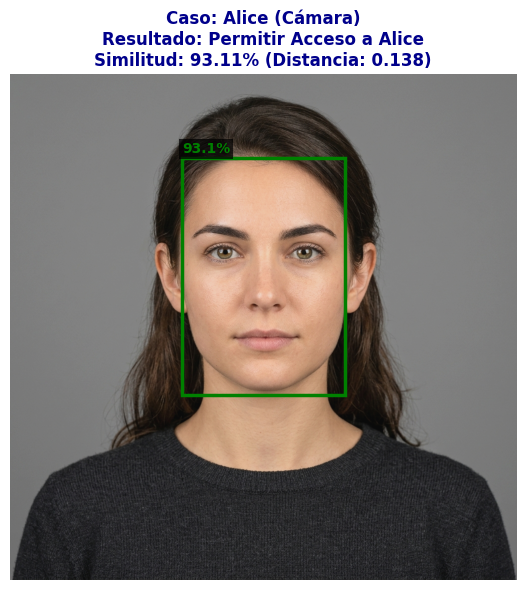

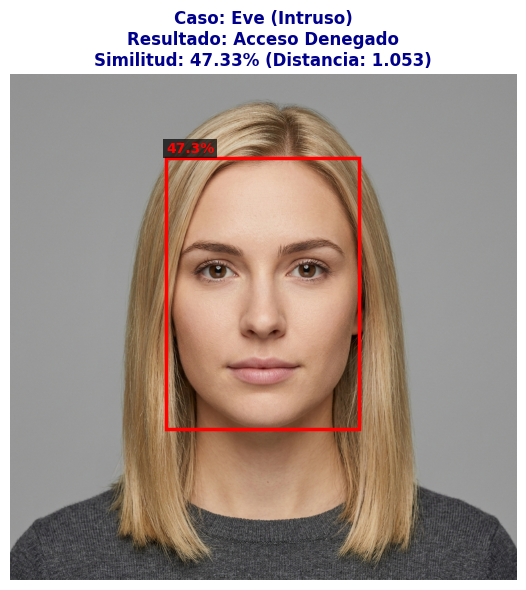

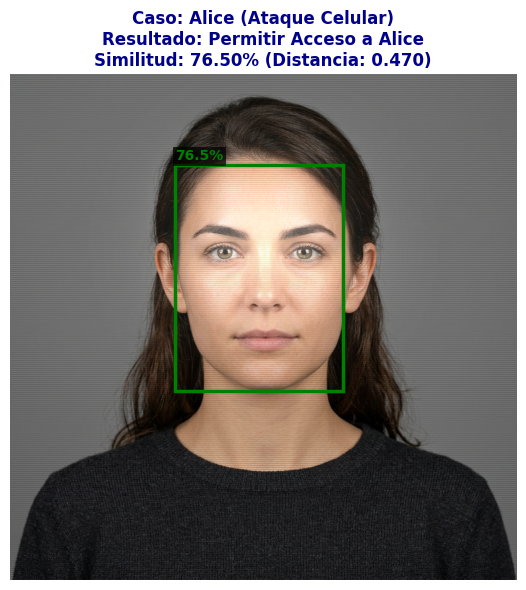

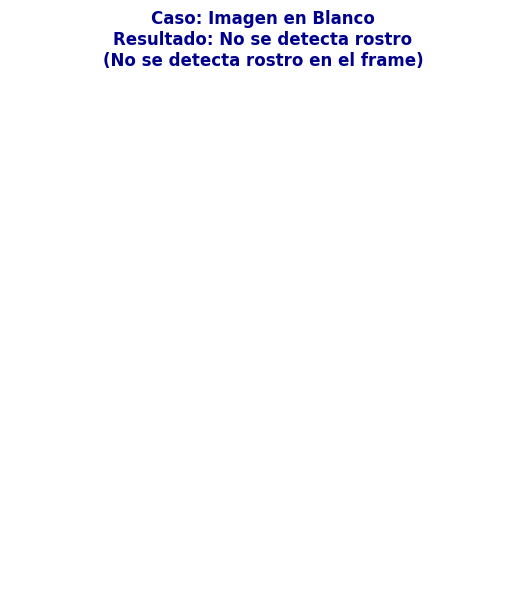

In [7]:
def plot_verification_result(frame_source, title_label="Prueba", threshold=0.6):
    status, dist, box, img = verify_access_details(frame_source, threshold)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.axis('off')
    
    title_text = f"Caso: {title_label}\nResultado: {status}"
    
    if box is not None:
        # Coordenadas de la caja de detección
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        
        # Color de la caja delimitadora (Verde = Permitido, Rojo = Denegado/No Reconocido)
        is_allowed = "Permitir Acceso" in status
        color = 'green' if is_allowed else 'red'
        
        rect = patches.Rectangle((x1, y1), w, h, linewidth=2.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        # Calcular porcentaje de similitud basado en distancia euclidiana L2
        if dist is not None:
            similarity = max(0.0, (1.0 - dist / 2.0)) * 100
            title_text += f"\nSimilitud: {similarity:.2f}% (Distancia: {dist:.3f})"
            
            # Etiqueta de similitud arriba de la caja
            ax.text(x1, y1 - 10, f"{similarity:.1f}%", color=color, weight='bold', fontsize=10,
                    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=2))
    else:
        title_text += "\n(No se detecta rostro en el frame)"
        
    plt.title(title_text, color='darkblue', fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

# Mostrar las visualizaciones de los cuatro casos de prueba
print("Generando gráficas de visualización...")
plot_verification_result(alice_cam, "Alice (Cámara)")
plot_verification_result(eve_cam, "Eve (Intruso)")
plot_verification_result(alice_spoof, "Alice (Ataque Celular)")
plot_verification_result(blank_img, "Imagen en Blanco")